# dq/dt from Maxwell's Equations: Solid-State Charge Transport

The continuity equation $\partial\rho/\partial t + \nabla\cdot\mathbf J = 0$
(charge only flows, never appears or vanishes) is not a separate postulate
-- it falls directly out of Ampere-Maxwell's law plus Gauss's law, and is
in fact the ACTUAL historical reason Maxwell added the displacement
current term. This notebook derives that, then applies the same equation
to two real solid-state charge-transport problems: semiconductor
drift-diffusion and dielectric relaxation. Engine:
`dgs/maxwell_solid_state_continuity.py`, reusing `dgs/causality.py`'s
`continuity_residual` and `dgs/transistor_tech.py`'s silicon permittivity.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import maxwell_solid_state_continuity as msc
from dgs.causality import continuity_residual
from dgs.transistor_tech import eps_si

sp.init_printing(use_latex="mathjax")
print("Setup complete.")


Setup complete.


## 1. Theory: Why Maxwell Added the Displacement Current

Plain Ampere's law, $\nabla\times\mathbf B=\mu_0\mathbf J$, has a fatal
problem: taking the divergence of BOTH sides, the left side is IDENTICALLY
zero ($\nabla\cdot(\nabla\times\text{anything})=0$, a vector-calculus
identity), forcing $\nabla\cdot\mathbf J=0$ always -- but that's false
whenever charge is accumulating anywhere (a charging capacitor, for
example). Maxwell's fix: add the displacement current
$\mu_0\epsilon_0\,\partial\mathbf E/\partial t$, so that the same
divergence argument, combined with Gauss's law
$\nabla\cdot\mathbf E=\rho/\epsilon_0$, gives EXACTLY the continuity
equation instead of the false $\nabla\cdot\mathbf J=0$.


## 2. Derivation, Verified Step by Step in SymPy


In [2]:
result = msc.derive_continuity_from_ampere_maxwell()
print(f"div(curl B) = 0 identically:  {result['div_curl_B_identity_holds']}")
print(f"Reduces to div(J) + drho/dt = 0 (not div(J)=0):  {result['matches_div_J_plus_drho_dt']}")
print()
print(result['conclusion'])


div(curl B) = 0 identically:  True
Reduces to div(J) + drho/dt = 0 (not div(J)=0):  True

div(curl B)=0 (identity) + Ampere-Maxwell + Gauss's law => div(J) + drho/dt = 0 exactly (the continuity equation), NOT div(J)=0 (what plain Ampere's law alone would force).


## 3. SymPy: Solid-State Drift-Diffusion Carrier Transport

Real semiconductor carrier transport combines DRIFT (mobility times
electric field) and DIFFUSION (spreading down a concentration gradient):

$$ \frac{\partial n}{\partial t} + v\frac{\partial n}{\partial x}
   = D\frac{\partial^2 n}{\partial x^2} $$

This has an EXACT closed-form solution -- a Gaussian that both drifts at
speed $v$ and spreads at rate $\sqrt{Dt}$ -- verified below to satisfy the
PDE exactly (SymPy reduces the residual to 0, not approximately).


In [3]:
ok = msc.verify_drift_diffusion_satisfies_pde()
print(f"n(x,t) satisfies dn/dt + v*dn/dx = D*d^2n/dx^2 exactly: {ok}")

x_sym, t_sym, v_sym, D_sym, N0_sym = sp.symbols('x t v D N_0', positive=True, real=True)
n_sym = N0_sym/sp.sqrt(4*sp.pi*D_sym*t_sym) * sp.exp(-(x_sym-v_sym*t_sym)**2/(4*D_sym*t_sym))
n_sym


n(x,t) satisfies dn/dt + v*dn/dx = D*d^2n/dx^2 exactly: True


               2 
    -(-t⋅v + x)  
    ─────────────
        4⋅D⋅t    
N₀⋅ℯ             
─────────────────
   2⋅√π⋅√D⋅√t    

## 4. Numerical Example: Charge Conservation, Checked (Not Assumed)

`continuity_residual` is `dgs/causality.py`'s existing, already-tested
function -- reused here directly, not reimplemented -- applied to a
genuinely spatially-varying (drifting AND spreading) carrier packet, so
the check is real: a spatially-uniform toy case would make
$\partial J/\partial x$ trivially zero and the check vacuous.


In [4]:
x = np.linspace(-20, 20, 400)
t = np.linspace(0.5, 4.5, 300)
v, D, q = 2.0, 0.8, 1.0

dd = msc.drift_diffusion_current_and_charge(x, t, v, D, N0=1.0, charge=q)
res = continuity_residual(dd['rho'], dd['J'], x, t)
interior = res[5:-5, 5:-5]
rel = np.max(np.abs(interior)) / np.max(np.abs(dd['rho']))
print(f"max|residual| = {np.max(np.abs(interior)):.2e}")
print(f"relative to max|rho| = {rel:.4f}  (charge conserved to within finite-difference grid error)")


max|residual| = 2.97e-03
relative to max|rho| = 0.0067  (charge conserved to within finite-difference grid error)


## 5. Plots: The Drifting, Spreading Charge Packet


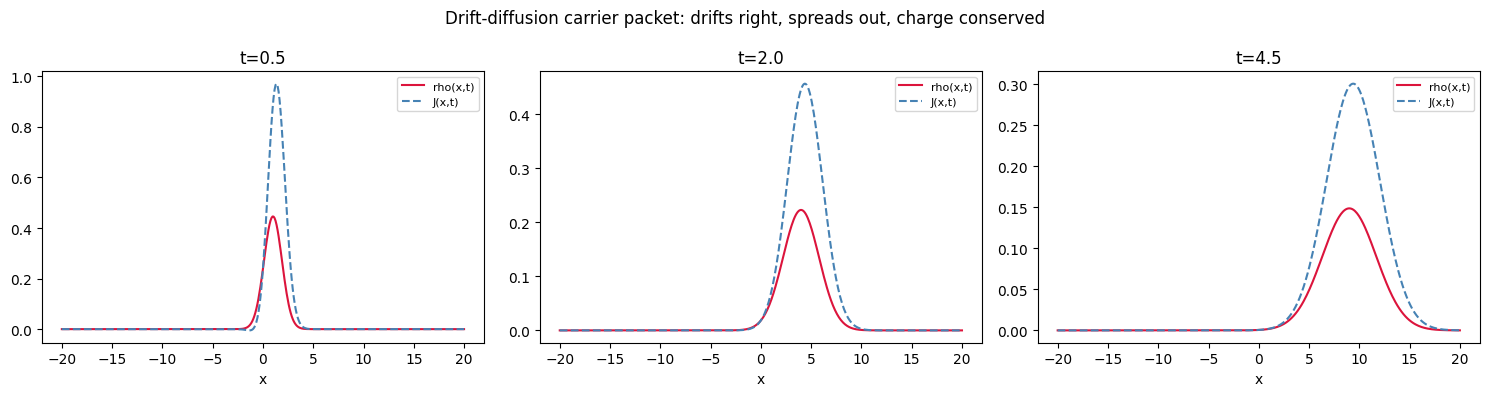

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, ti in zip(axes, [0.5, 2.0, 4.5]):
    idx = np.argmin(np.abs(t - ti))
    ax.plot(x, dd['rho'][idx], color='crimson', label='rho(x,t)')
    ax.plot(x, dd['J'][idx], color='steelblue', label='J(x,t)', ls='--')
    ax.set_title(f't={ti}')
    ax.set_xlabel('x')
    ax.legend(fontsize=8)
fig.suptitle('Drift-diffusion carrier packet: drifts right, spreads out, charge conserved')
plt.tight_layout()
plt.savefig('drift_diffusion_snapshots.png', dpi=100, bbox_inches='tight')
plt.show()


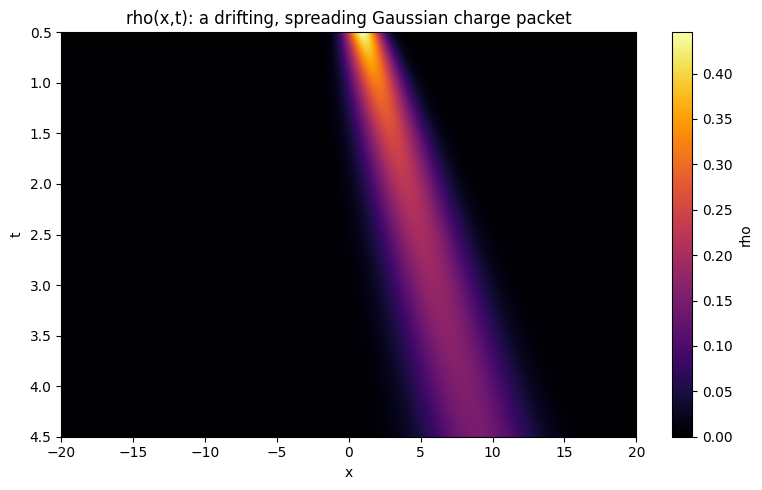

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(dd['rho'], extent=[x[0], x[-1], t[-1], t[0]], aspect='auto', cmap='inferno')
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title('rho(x,t): a drifting, spreading Gaussian charge packet')
plt.colorbar(im, ax=ax, label='rho')
plt.tight_layout()
plt.savefig('drift_diffusion_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Parameter Sweep: Solid-State Dielectric Relaxation

Excess charge injected into a conductor or semiconductor relaxes toward
neutrality as $\rho(t)=\rho_0 e^{-t/\tau}$, $\tau=\epsilon/\sigma$ --
derived from Ohm's law + Gauss's law + continuity via `sp.dsolve` below,
then swept across conductivities spanning lightly-doped to heavily-doped
silicon (using `dgs/transistor_tech.py`'s real $\epsilon_{Si}$, not a
new constant).


In [7]:
ode_sol = msc.derive_dielectric_relaxation_ode()
ode_sol


           -t 
           ───
            τ 
ρ(t) = ρ₀⋅ℯ   

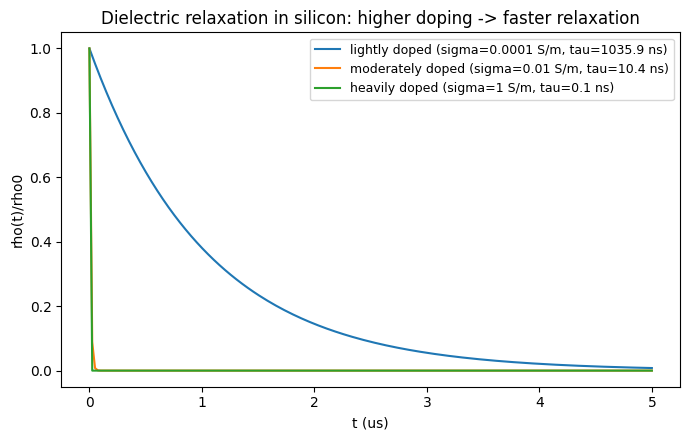

In [8]:
t_arr = np.linspace(0, 5e-6, 200)
fig, ax = plt.subplots(figsize=(7,4.5))
for sigma, label in [(1e-4, 'lightly doped'), (1e-2, 'moderately doped'), (1.0, 'heavily doped')]:
    tau = msc.dielectric_relaxation_time(eps_si, sigma)
    rho_t = msc.dielectric_relaxation_decay(t_arr, rho0=1.0, tau=tau)
    ax.plot(t_arr*1e6, rho_t, label=f'{label} (sigma={sigma:g} S/m, tau={tau*1e9:.1f} ns)')
ax.set_xlabel('t (us)'); ax.set_ylabel('rho(t)/rho0')
ax.set_title('Dielectric relaxation in silicon: higher doping -> faster relaxation')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('dielectric_relaxation_sweep.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Engineering Interpretation

- Drift-diffusion (section 3-5) is the actual PDE real semiconductor
  device simulators (TCAD tools) solve numerically for arbitrary
  geometries/doping profiles -- this notebook's closed-form Gaussian is
  the exactly-solvable special case (uniform field, no recombination),
  useful as a correctness baseline for any numerical solver.
- Dielectric relaxation time (section 6) sets a real design constraint:
  if a semiconductor device's operating frequency is faster than
  $1/\tau$, excess charge doesn't have time to relax before the field
  changes again -- relevant to RF/high-speed device design, not just a
  textbook time constant.


## 8. Research Discussion

- Section 3-5's exact solution assumes a UNIFORM drift field and no
  generation/recombination -- the full semiconductor continuity equation
  used in real device physics adds a G-R term:
  $\partial n/\partial t = (1/q)\partial J_n/\partial x + G - R$. Worth
  extending this module to include a simple G-R model (e.g. Shockley-Read-Hall)
  and checking whether continuity_residual still holds once that source
  term is properly accounted for.
- Could the same `derive_continuity_from_ampere_maxwell` derivation
  pattern be extended to show, symbolically, why the SAME requirement
  (self-consistency with continuity) also determines the exact coefficient
  in front of the displacement current term (not just its existence)?


## 9. Possible Experiments

1. Add a Shockley-Read-Hall recombination term to
   `drift_diffusion_current_and_charge` and verify continuity_residual now
   correctly shows a NONZERO residual matching the added source term (a
   genuine check that continuity_residual detects a real source, not just
   confirming zero when there is none).
2. Sweep `v` and `D` in the drift-diffusion example and quantify how the
   continuity_residual's relative error scales with the grid resolution
   (x, t sample counts) -- confirming it's genuinely finite-difference
   truncation error, not a real physics violation.
3. Compare the dielectric relaxation time against a REAL measured silicon
   conductivity value (not the order-of-magnitude placeholder used in
   section 6) for a specific doping concentration, citing a real source.


## 10. Future Improvements

- If this module grows a full drift-diffusion NUMERICAL solver (not just
  the exact closed-form special case), it would be a genuinely useful
  complement to `dgs/gs_core.py`'s optics-side inverse-problem tooling --
  a forward semiconductor-device solver, verified against this notebook's
  exact solution as a correctness baseline.
- Cross-link this notebook from `dgs/causality.py`'s own module docstring
  (a "see also, applied to solid-state transport" pointer), since this
  notebook's section 4 is the first real reuse of continuity_residual
  outside dgs/curl_div_modern_physics.py's quantum case.
